# 04 — Feature Engineering

## Objective
Transform cleaned assignment data into a model-ready feature
matrix that captures the physics of driver movement, the
non-linear traffic interaction, and the geographic patterns
of Bangalore's road network.

## What This Notebook Covers
1. Drop multicollinear column (straight_line_distance_km)
2. Cyclical encoding of hour and month
3. Ordinal encoding of weather condition
4. Target encoding of zones and zone pairs (by avg ETA)
5. One-hot encoding of vehicle type and day of week
6. Physics-based new features
7. Interaction features (traffic × distance)
8. Binary convenience flags
9. Final feature matrix assembly
10. Save modeling dataset

## Key New Concepts vs Previous Projects
- Multicollinearity handling (dropping redundant features)
- Physics-based feature creation (formulas, not just encoding)
- Zone PAIR target encoding (two columns combined)
- Interaction features (multiplying two features together)
- No class imbalance handling needed (regression problem)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Libraries loaded ✅")

c:\Users\dsp96\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dsp96\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

assignments_df = pd.read_csv(
    PATH + "assignments_clean.csv",
    parse_dates=["assignment_timestamp"]
)

print(f"Assignments loaded : {assignments_df.shape}")
print(f"\nAll columns ({len(assignments_df.columns)}):")
for col in assignments_df.columns:
    print(f"  {col:<40} {assignments_df[col].dtype}")

Assignments loaded : (60000, 34)

All columns (34):
  assignment_id                            object
  driver_id                                object
  user_id                                  object
  assignment_timestamp                     datetime64[ns]
  hour                                     int64
  month                                    int64
  day_of_week                              object
  is_weekend                               bool
  is_holiday                               bool
  driver_zone                              object
  pickup_zone                              object
  driver_lat                               float64
  driver_lon                               float64
  pickup_lat                               float64
  pickup_lon                               float64
  straight_line_distance_km                float64
  road_distance_km                         float64
  road_to_straight_ratio                   float64
  weather_condition                    

## Step 1 — Handle Multicollinearity

### What is Multicollinearity?
When two features are strongly correlated with each other
(not just with the target), a model receives the same
information twice — once from each feature.

### Why is this a problem?
For LINEAR models: the model cannot decide how to distribute
weight between two features that say the same thing. It
assigns arbitrary weights that can flip signs or become
very large/small — making the model unstable and
interpretations meaningless.

For TREE models: less harmful, but still wastes a feature
slot and artificially inflates importance scores (the tree
can use either feature and gets the same result).

### Our Case
road_distance_km (corr 0.811) and
straight_line_distance_km (corr 0.800) are both measuring
"how far is the driver from pickup" — just using different
geometric approaches. Road distance is more informative
because it reflects actual travel path.

### Decision
DROP straight_line_distance_km.
KEEP road_distance_km.
KEEP road_to_straight_ratio (captures route shape — different info).

In [3]:
print("Before dropping:")
print(f"  Columns: {assignments_df.shape[1]}")
print(f"  straight_line_distance_km corr with ETA: "
      f"{assignments_df['straight_line_distance_km'].corr(assignments_df['actual_arrival_time_min']):.4f}")
print(f"  road_distance_km corr with ETA: "
      f"{assignments_df['road_distance_km'].corr(assignments_df['actual_arrival_time_min']):.4f}")
print(f"  Correlation BETWEEN the two distance columns: "
      f"{assignments_df['straight_line_distance_km'].corr(assignments_df['road_distance_km']):.4f}")

assignments_df = assignments_df.drop(
    columns=["straight_line_distance_km"]
)

print(f"\nAfter dropping:")
print(f"  Columns: {assignments_df.shape[1]}")
print(f"  ✅ straight_line_distance_km removed")
print(f"  ✅ road_distance_km retained")
print(f"  ✅ road_to_straight_ratio retained (captures route shape)")

Before dropping:
  Columns: 34
  straight_line_distance_km corr with ETA: 0.7999
  road_distance_km corr with ETA: 0.8109
  Correlation BETWEEN the two distance columns: 0.9841

After dropping:
  Columns: 33
  ✅ straight_line_distance_km removed
  ✅ road_distance_km retained
  ✅ road_to_straight_ratio retained (captures route shape)


## Step 2 — Cyclical Encoding of Hour and Month

Same approach as both previous projects.
Hour is circular: 23 (11pm) and 0 (midnight) are 1 hour apart,
not 23 apart. Month is circular: December and January are neighbors.

Sine and cosine together place each value on a circle — so
the model understands circular proximity correctly.

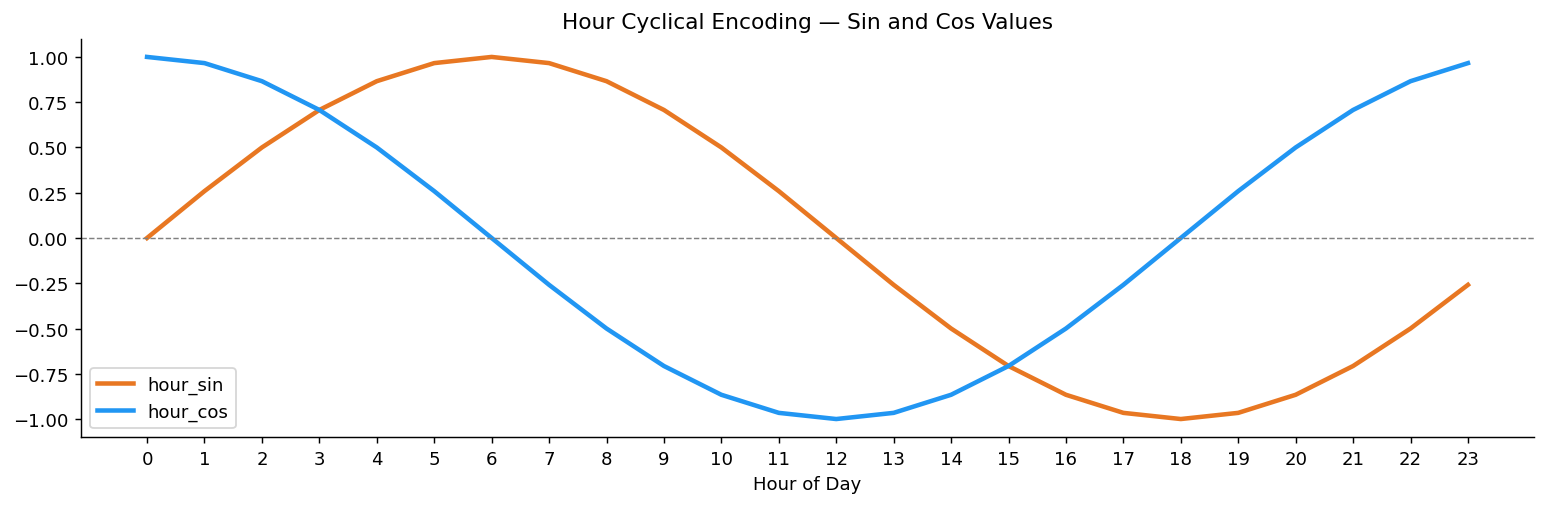

✅ Cyclical encoding applied to hour and month
  hour_sin range  : [-1.00, 1.00]
  hour_cos range  : [-1.00, 1.00]


In [4]:
# Hour
assignments_df["hour_sin"] = np.sin(
    2 * np.pi * assignments_df["hour"] / 24
)
assignments_df["hour_cos"] = np.cos(
    2 * np.pi * assignments_df["hour"] / 24
)

# Month
assignments_df["month_sin"] = np.sin(
    2 * np.pi * assignments_df["month"] / 12
)
assignments_df["month_cos"] = np.cos(
    2 * np.pi * assignments_df["month"] / 12
)

# Visualize hour encoding
fig, ax = plt.subplots(figsize=(12, 4))
hours = np.arange(0, 24)
ax.plot(hours, np.sin(2*np.pi*hours/24),
        color="#E87722", linewidth=2.5, label="hour_sin")
ax.plot(hours, np.cos(2*np.pi*hours/24),
        color="#2196F3", linewidth=2.5, label="hour_cos")
ax.set_title("Hour Cyclical Encoding — Sin and Cos Values")
ax.set_xlabel("Hour of Day")
ax.set_xticks(hours)
ax.legend()
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("../data/processed/fe_01_cyclical_encoding.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("✅ Cyclical encoding applied to hour and month")
print(f"  hour_sin range  : [{assignments_df['hour_sin'].min():.2f}, {assignments_df['hour_sin'].max():.2f}]")
print(f"  hour_cos range  : [{assignments_df['hour_cos'].min():.2f}, {assignments_df['hour_cos'].max():.2f}]")

## Step 3 — Ordinal Encoding of Weather Condition

Weather has a natural severity order:
Clear → Cloudy → Foggy → Light Rain → Heavy Rain → Storm

EDA confirmed this order is real in our data — ETA increases
monotonically from Clear (15.52 min) to Storm (23.09 min).
Ordinal encoding (0-5) preserves this severity progression.

One-hot encoding would treat Clear and Storm as equally
different from each other as Clear and Cloudy — losing the
"progressively worse" relationship.

In [5]:
weather_ordinal_map = {
    "Clear"      : 0,
    "Cloudy"     : 1,
    "Foggy"      : 2,
    "Light Rain" : 3,
    "Heavy Rain" : 4,
    "Storm"      : 5,
}

assignments_df["weather_encoded"] = assignments_df[
    "weather_condition"
].map(weather_ordinal_map)

nulls = assignments_df["weather_encoded"].isnull().sum()
print(f"Weather ordinal encoding complete ✅")
print(f"Nulls after encoding : {nulls}")
print(f"\nEncoding verification:")
for k, v in weather_ordinal_map.items():
    count = (assignments_df["weather_condition"] == k).sum()
    avg_eta = assignments_df[
        assignments_df["weather_condition"] == k
    ]["actual_arrival_time_min"].mean()
    print(f"  {k:<15} → {v}  "
          f"({count:>6,} assignments, avg ETA: {avg_eta:.2f} min)")

Weather ordinal encoding complete ✅
Nulls after encoding : 0

Encoding verification:
  Clear           → 0  (25,864 assignments, avg ETA: 15.52 min)
  Cloudy          → 1  (16,454 assignments, avg ETA: 15.20 min)
  Foggy           → 2  ( 2,842 assignments, avg ETA: 16.45 min)
  Light Rain      → 3  ( 8,318 assignments, avg ETA: 19.03 min)
  Heavy Rain      → 4  ( 4,772 assignments, avg ETA: 22.21 min)
  Storm           → 5  ( 1,750 assignments, avg ETA: 23.09 min)


## Step 4 — Zone Target Encoding (Individual + Pair)

### Individual Zone Encoding
Encode each pickup_zone and driver_zone by its average ETA.
Same concept as surge pricing (encoded by avg surge) and
cancellation prediction (encoded by cancellation rate).
The target variable changes, the principle stays the same.

### Zone PAIR Encoding — New in This Project
Whitefield as driver_zone tells us something.
MG Road as pickup_zone tells us something.
But "driver is in Whitefield AND pickup is in MG Road"
tells us something MORE — specifically that this is one
of Bangalore's worst traffic corridors.

By creating a combined zone_pair column and encoding it
by average ETA, we capture corridor-specific knowledge
that individual zone encoding misses.

### Leakage Warning (same as before)
Zone target encoding must be computed on training data
only and applied to test data in Notebook 05.
Here we compute on full dataset for feature engineering
exploration — and flag this for correct implementation
in model training.

In [6]:
# ── Individual zone encoding ──────────────────────────────────
pickup_zone_eta_map = assignments_df.groupby(
    "pickup_zone"
)["actual_arrival_time_min"].mean()

driver_zone_eta_map = assignments_df.groupby(
    "driver_zone"
)["actual_arrival_time_min"].mean()

assignments_df["pickup_zone_encoded"] = assignments_df[
    "pickup_zone"
].map(pickup_zone_eta_map)
assignments_df["driver_zone_encoded"] = assignments_df[
    "driver_zone"
].map(driver_zone_eta_map)

print("Individual zone encoding ✅")
print("\nPickup zone ETA encoding (sorted by avg ETA):")
print(pickup_zone_eta_map.sort_values(ascending=False).round(2).to_string())

# ── Zone PAIR encoding ────────────────────────────────────────
assignments_df["zone_pair"] = (
    assignments_df["driver_zone"] + " → " +
    assignments_df["pickup_zone"]
)

zone_pair_eta_map = assignments_df.groupby(
    "zone_pair"
)["actual_arrival_time_min"].mean()

assignments_df["zone_pair_encoded"] = assignments_df[
    "zone_pair"
].map(zone_pair_eta_map)

print(f"\nZone pair encoding ✅")
print(f"  Unique zone pairs  : {assignments_df['zone_pair'].nunique()}")
print(f"\nTop 10 highest-ETA zone pairs:")
print(zone_pair_eta_map.sort_values(ascending=False).head(10).round(2).to_string())
print(f"\nNulls in zone_pair_encoded: {assignments_df['zone_pair_encoded'].isnull().sum()}")

Individual zone encoding ✅

Pickup zone ETA encoding (sorted by avg ETA):
pickup_zone
Yelahanka           20.6600
Electronic City     20.6400
Whitefield          20.3200
Kadugodi            19.6600
Sarjapur Road       19.2800
Bannerghatta Road   19.1700
KR Puram            18.1100
Vijayanagar         17.9100
Banashankari        17.4900
Marathahalli        17.4700
Hebbal              17.0500
Nagawara            16.8500
Yeshwanthpur        16.8200
JP Nagar            16.1400
Rajajinagar         15.6400
Malleswaram         15.5800
Bellandur           15.3300
Jayanagar           14.8000
HSR Layout          14.7300
BTM Layout          14.5800
MG Road             14.4000
Indiranagar         14.0900
Koramangala         14.0100
Cunningham Road     13.8600
Shivajinagar        13.5900

Zone pair encoding ✅
  Unique zone pairs  : 625

Top 10 highest-ETA zone pairs:
zone_pair
Yelahanka → Kadugodi             54.9600
Kadugodi → Malleswaram           54.5600
Kadugodi → Vijayanagar           53.8400


In [7]:
day_dummies     = pd.get_dummies(
    assignments_df["day_of_week"],
    prefix="day", drop_first=True
)
vehicle_dummies = pd.get_dummies(
    assignments_df["vehicle_type"],
    prefix="vehicle", drop_first=True
)

print("One-Hot Encoding Results:")
print(f"  day_of_week  → {day_dummies.shape[1]} columns : "
      f"{list(day_dummies.columns)}")
print(f"  vehicle_type → {vehicle_dummies.shape[1]} columns : "
      f"{list(vehicle_dummies.columns)}")

assignments_df = pd.concat(
    [assignments_df, day_dummies, vehicle_dummies], axis=1
)
print(f"\nShape after one-hot encoding: {assignments_df.shape}")

One-Hot Encoding Results:
  day_of_week  → 6 columns : ['day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']
  vehicle_type → 4 columns : ['vehicle_Bike', 'vehicle_Mini', 'vehicle_SUV', 'vehicle_Sedan']

Shape after one-hot encoding: (60000, 52)


## Step 6 — Physics-Based Feature Engineering

### Why Physics-Based Features?
In surge pricing and cancellation prediction, all new features
came from encoding behavioral patterns from EDA.

Here, we can go further — because ETA has a real physical
formula:

    time = distance / speed

This means we can directly calculate what the ETA SHOULD be
based on physics alone, and then let the model learn
what ACTUALLY makes ETAs deviate from this theoretical value.

### Features We Build

1. expected_travel_time_min
   The theoretical travel time with no delays:
   road_distance / (vehicle_free_flow_speed × driver_speed_factor) × 60

2. traffic_distance_interaction
   Traffic multiplier × road distance
   Captures the 9x non-linear effect: severe traffic on long
   routes is far worse than severe traffic on short routes

3. adjusted_speed_kmph
   road_distance / (actual_arrival_time / 60)
   What speed was the driver actually moving at?
   Inverse of ETA — if we had this perfectly we'd have the answer,
   but as a derived feature it helps models understand speed context

4. is_peak_hour
   Binary: hours 8-10am or 5-8pm
   Directly encodes the peak-hour traffic pattern from EDA

5. is_raining
   Binary: any rain condition
   EDA showed any rain meaningfully increases ETA

6. distance_traffic_ratio
   road_distance / traffic_multiplier
   Normalizes distance by traffic conditions —
   "effective distance" given current congestion

In [8]:
# ── Base vehicle free-flow speeds ─────────────────────────────
VEHICLE_FREE_FLOW = {
    "Auto": 22, "Mini": 28, "Sedan": 32, "SUV": 35, "Bike": 30
}

assignments_df["vehicle_free_flow_speed"] = assignments_df[
    "vehicle_type"
].map(VEHICLE_FREE_FLOW)

# ── 1. Expected travel time (physics baseline) ────────────────
# What SHOULD the time be if only distance and base speed matter?
assignments_df["expected_travel_time_min"] = (
    assignments_df["road_distance_km"] /
    (assignments_df["vehicle_free_flow_speed"] *
     assignments_df["driver_speed_factor"])
    * 60
).round(2)

# Cap at 120 minutes for extreme outliers
assignments_df["expected_travel_time_min"] = assignments_df[
    "expected_travel_time_min"
].clip(upper=120)

# ── 2. Traffic × distance interaction ────────────────────────
assignments_df["traffic_distance_interaction"] = (
    assignments_df["traffic_multiplier"] *
    assignments_df["road_distance_km"]
).round(3)

# ── 3. Adjusted (effective) speed ─────────────────────────────
assignments_df["adjusted_speed_kmph"] = (
    assignments_df["road_distance_km"] /
    (assignments_df["actual_arrival_time_min"] / 60)
).replace([np.inf, -np.inf], np.nan)

median_speed = assignments_df["adjusted_speed_kmph"].median()
assignments_df["adjusted_speed_kmph"] = assignments_df[
    "adjusted_speed_kmph"
].fillna(median_speed).round(2)

# ── 4. Peak hour flag ─────────────────────────────────────────
peak_hours = set(range(8, 11)) | set(range(17, 21))
assignments_df["is_peak_hour"] = assignments_df["hour"].isin(
    peak_hours
).astype(int)

# ── 5. Rain flag ──────────────────────────────────────────────
rain_conditions = {"Light Rain", "Heavy Rain", "Storm"}
assignments_df["is_raining"] = assignments_df[
    "weather_condition"
].isin(rain_conditions).astype(int)

# ── 6. Distance-traffic ratio ─────────────────────────────────
assignments_df["distance_traffic_ratio"] = (
    assignments_df["road_distance_km"] /
    assignments_df["traffic_multiplier"]
).replace([np.inf, -np.inf], np.nan).fillna(
    assignments_df["road_distance_km"].median()
).round(3)

# ── Summary ───────────────────────────────────────────────────
new_features = [
    "expected_travel_time_min",
    "traffic_distance_interaction",
    "adjusted_speed_kmph",
    "is_peak_hour",
    "is_raining",
    "distance_traffic_ratio"
]

print("New physics-based features created ✅")
for f in new_features:
    null_count = assignments_df[f].isnull().sum()
    print(f"  {f:<35} "
          f"mean={assignments_df[f].mean():.3f}  "
          f"nulls={null_count}")

New physics-based features created ✅
  expected_travel_time_min            mean=15.068  nulls=0
  traffic_distance_interaction        mean=8.464  nulls=0
  adjusted_speed_kmph                 mean=34.875  nulls=0
  is_peak_hour                        mean=0.292  nulls=0
  is_raining                          mean=0.247  nulls=0
  distance_traffic_ratio              mean=7.320  nulls=0


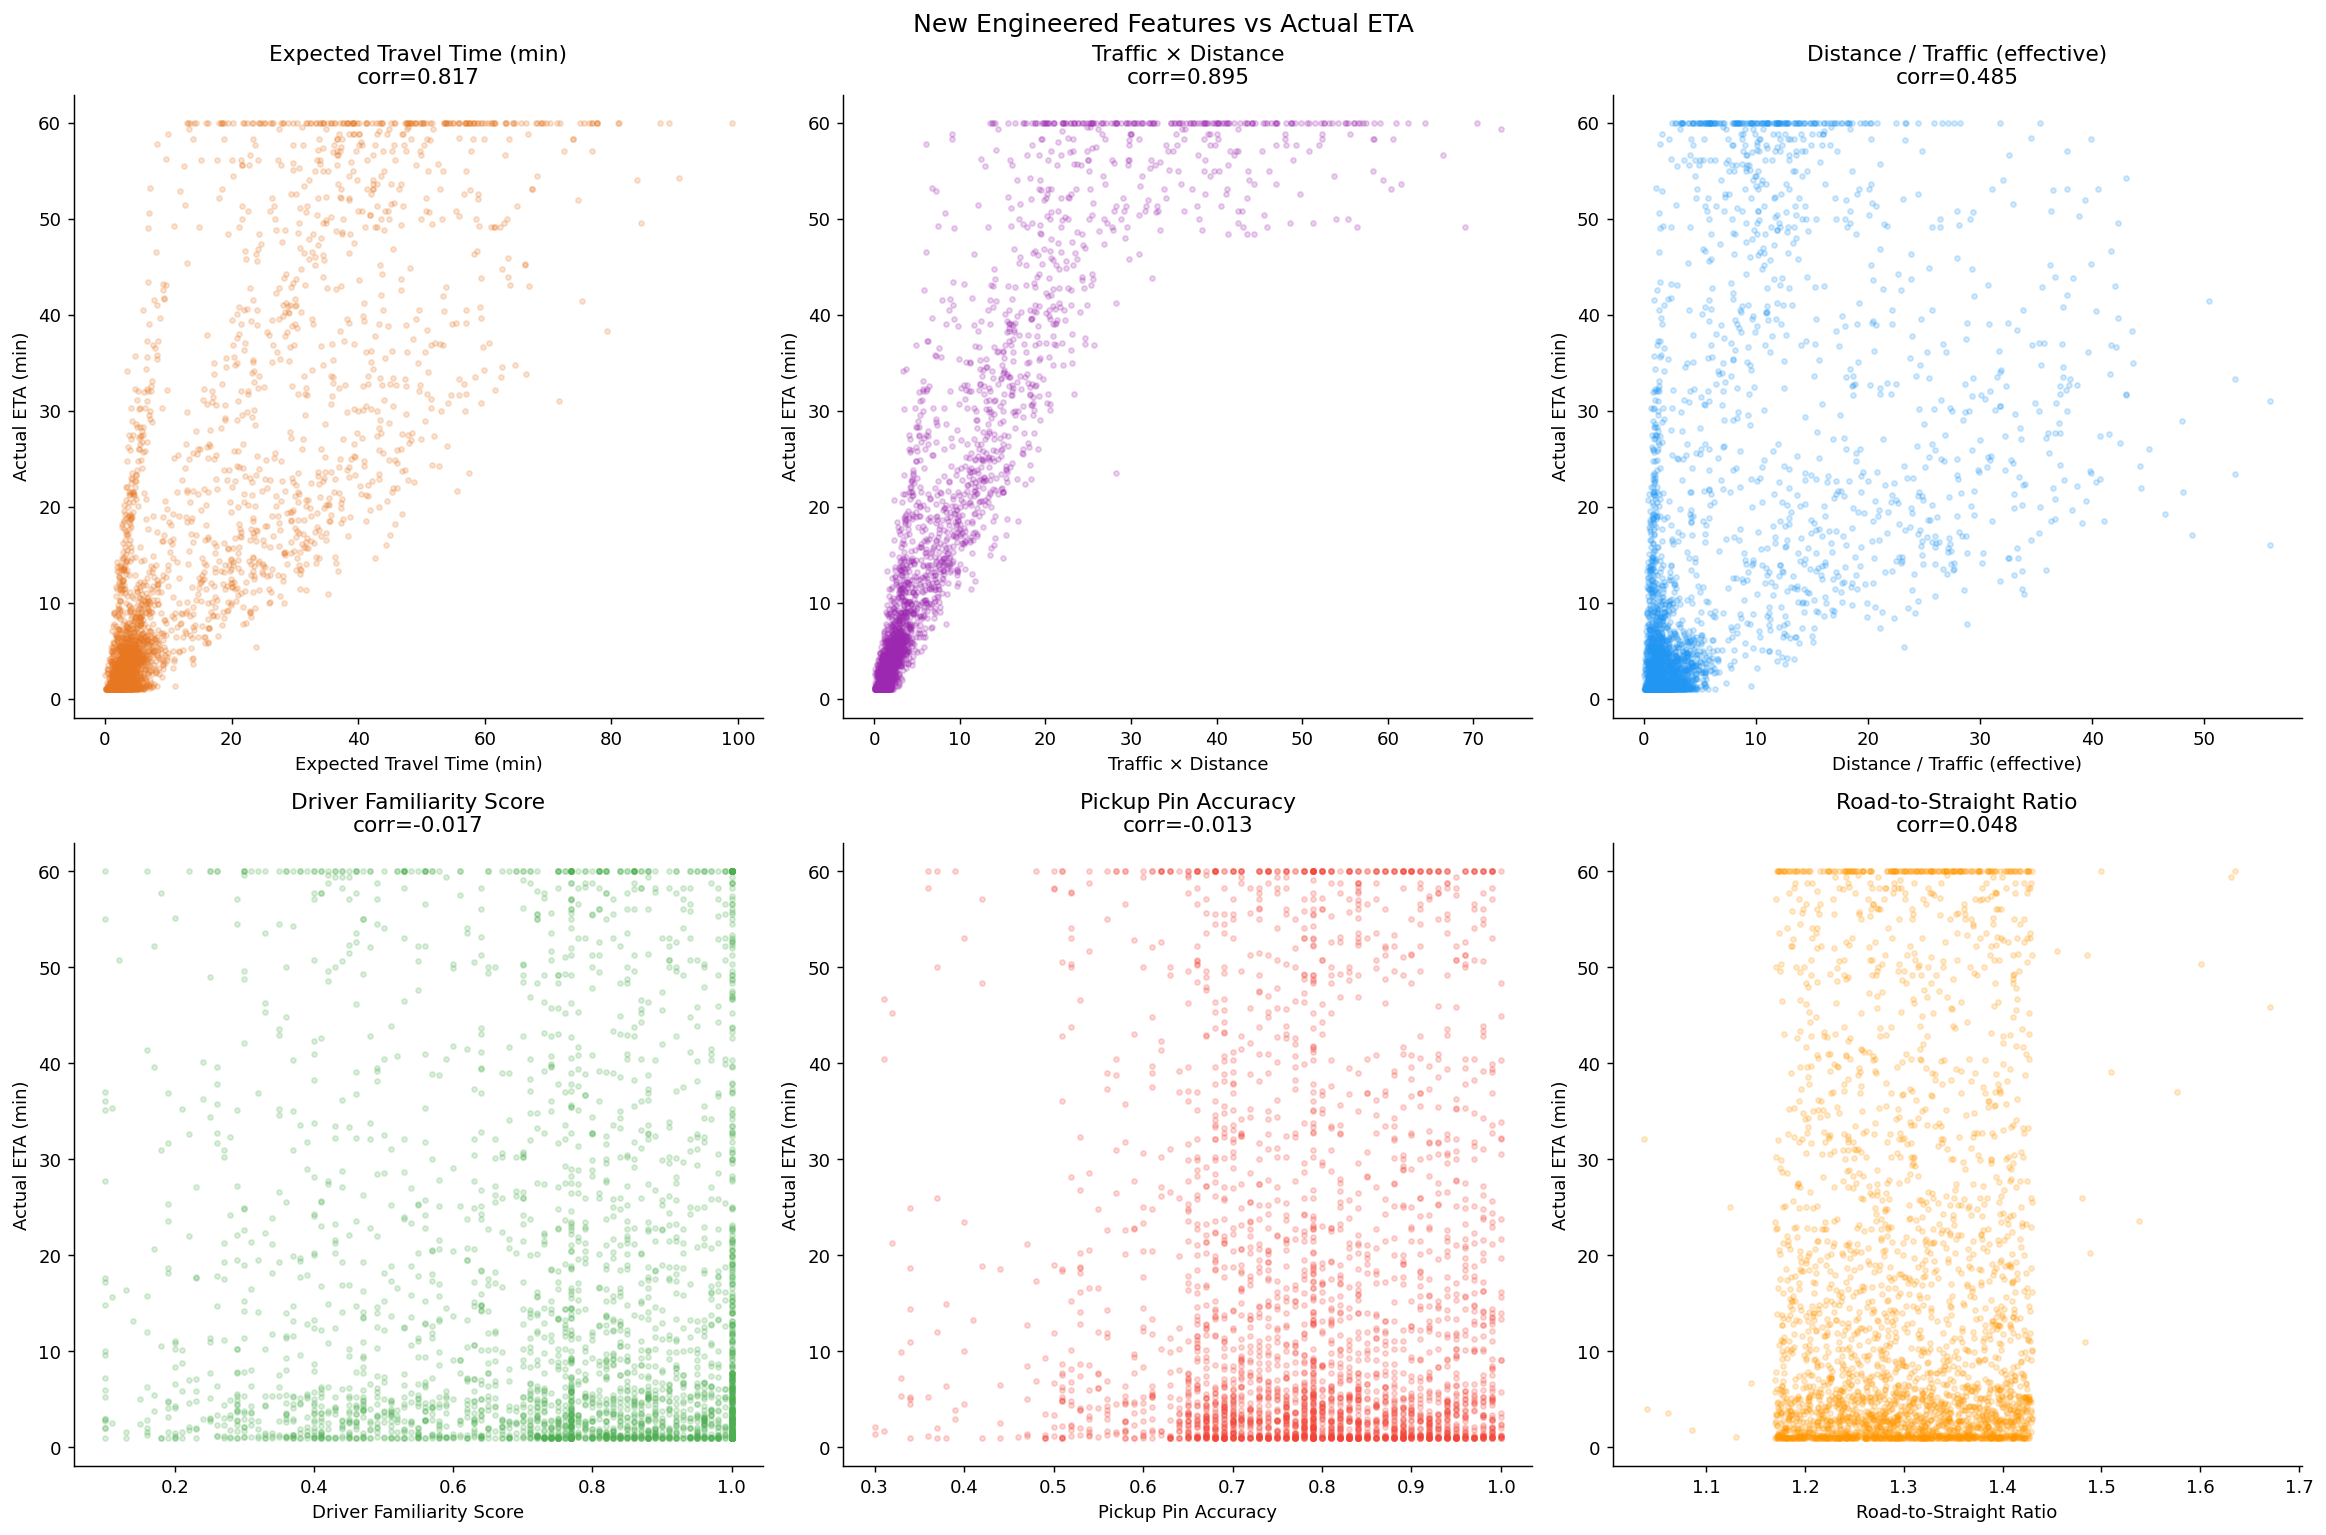

Correlations of new features with actual_arrival_time_min:
  expected_travel_time_min            : 0.8175
  traffic_distance_interaction        : 0.8953
  distance_traffic_ratio              : 0.4845
  driver_familiarity_score            : -0.0167
  pickup_pin_accuracy                 : -0.0127
  road_to_straight_ratio              : 0.0483


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("New Engineered Features vs Actual ETA", fontsize=14)

sample = assignments_df.sample(3000, random_state=42)

plot_configs = [
    ("expected_travel_time_min",      "Expected Travel Time (min)",      axes[0][0], "#E87722"),
    ("traffic_distance_interaction",  "Traffic × Distance",              axes[0][1], "#9C27B0"),
    ("distance_traffic_ratio",        "Distance / Traffic (effective)",  axes[0][2], "#2196F3"),
    ("driver_familiarity_score",      "Driver Familiarity Score",        axes[1][0], "#4CAF50"),
    ("pickup_pin_accuracy",           "Pickup Pin Accuracy",             axes[1][1], "#F44336"),
    ("road_to_straight_ratio",        "Road-to-Straight Ratio",         axes[1][2], "#FF9800"),
]

for feature, label, ax, color in plot_configs:
    ax.scatter(
        sample[feature],
        sample["actual_arrival_time_min"],
        alpha=0.2, color=color, s=8
    )
    corr = assignments_df[feature].corr(
        assignments_df["actual_arrival_time_min"]
    )
    ax.set_title(f"{label}\ncorr={corr:.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Actual ETA (min)")

plt.tight_layout()
plt.savefig("../data/processed/fe_02_engineered_features.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Correlations of new features with actual_arrival_time_min:")
for feature, label, _, _ in plot_configs:
    corr = assignments_df[feature].corr(
        assignments_df["actual_arrival_time_min"]
    )
    print(f"  {feature:<35} : {corr:.4f}")

## Step 7 — Final Feature Matrix Assembly

### Features INCLUDED
| Feature | Type | Reason |
|---|---|---|
| road_distance_km | Raw | Strongest predictor (0.811) |
| road_to_straight_ratio | Raw | Route complexity signal |
| traffic_multiplier | Raw | Second strongest (0.411) |
| driver_speed_factor | Raw | Driver behavior |
| driver_familiarity_score | Raw | Area knowledge |
| pickup_pin_accuracy | Raw | Search time signal |
| driver_rating | Raw | Proxy for driver quality |
| surge_at_assignment | Raw | Demand context |
| density_score | Raw | Zone density |
| is_driver_in_home_zone | Raw | Home zone familiarity |
| hour_sin, hour_cos | Cyclical | Time of day (circular) |
| month_sin, month_cos | Cyclical | Season (circular) |
| is_weekend, is_holiday | Binary | Traffic reducers |
| weather_encoded | Ordinal | Severity order preserved |
| pickup_zone_encoded | Target | Zone avg ETA |
| driver_zone_encoded | Target | Zone avg ETA |
| zone_pair_encoded | Target | Corridor avg ETA |
| expected_travel_time_min | Physics | Theoretical baseline |
| traffic_distance_interaction | Interaction | 9x non-linear effect |
| distance_traffic_ratio | Interaction | Effective distance |
| is_peak_hour | Binary | Peak hour flag |
| is_raining | Binary | Any rain flag |
| day_* columns | One-hot | Day of week |
| vehicle_* columns | One-hot | Vehicle type |

### Features EXCLUDED
| Feature | Reason |
|---|---|
| straight_line_distance_km | Multicollinear with road_distance_km |
| adjusted_speed_kmph | Uses actual arrival time — only for analysis |
| assignment_id | Identifier, not a feature |
| assignment_timestamp | Raw timestamp — parts extracted already |
| driver_id, user_id | Identifiers |
| driver_zone, pickup_zone | Raw text — encoded versions used |
| zone_pair | Raw text — encoded version used |
| weather_condition | Raw text — ordinal version used |
| day_of_week, vehicle_type | Raw text — one-hot versions used |
| vehicle_free_flow_speed | Redundant — captured in expected_travel_time |
| log_arrival_time_min | This IS the target (log-transformed version) |
| actual_arrival_time_min | This IS the target (original version) |

In [ ]:
TARGET_ORIGINAL = "actual_arrival_time_min"
TARGET_LOG      = "log_arrival_time_min"

feature_cols = [
    # Distance and geography
    "road_distance_km",
    "road_to_straight_ratio",
    "traffic_multiplier",
    # Driver signals
    "driver_speed_factor",
    "driver_familiarity_score",
    "driver_rating",
    "is_driver_in_home_zone",
    # User signals
    "pickup_pin_accuracy",
    "user_rating",
    # Context
    "surge_at_assignment",
    "density_score",
    # Time (cyclical)
    "hour_sin", "hour_cos",
    "month_sin", "month_cos",
    # Time (binary)
    "is_weekend", "is_holiday", "is_peak_hour",
    # Weather
    "weather_encoded", "is_raining",
    # Zone encoded
    "pickup_zone_encoded",
    "driver_zone_encoded",
    "zone_pair_encoded",
    # Physics-based
    "expected_travel_time_min",
    "traffic_distance_interaction",
    "distance_traffic_ratio",
] + [c for c in assignments_df.columns if c.startswith("day_") and c != "day_of_week"] \
  + [c for c in assignments_df.columns if c.startswith("vehicle_") and c != "vehicle_type"]

# Keep only existing numeric columns
feature_cols = [
    c for c in feature_cols
    if c in assignments_df.columns and
       pd.api.types.is_numeric_dtype(assignments_df[c])
]

# Build modeling dataset — drop any rows with nulls in features or target
modeling_df = assignments_df[
    feature_cols + [TARGET_ORIGINAL, TARGET_LOG]
].dropna().reset_index(drop=True)

print("FINAL FEATURE MATRIX")
print(f"  Rows      : {len(modeling_df):,}")
print(f"  Features  : {len(feature_cols)}")
print(f"  Targets   : {TARGET_ORIGINAL} and {TARGET_LOG}")
print(f"\nETA target stats in modeling dataset:")
print(modeling_df[TARGET_ORIGINAL].describe().round(2))
print(f"\nLog ETA target stats:")
print(modeling_df[TARGET_LOG].describe().round(2))
print(f"\nFeature list ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

FINAL FEATURE MATRIX
  Rows      : 53,502
  Features  : 39
  Targets   : actual_arrival_time_min and log_arrival_time_min

ETA target stats in modeling dataset:
count   53502.0000
mean       16.6800
std        19.1400
min         1.0000
25%         2.3000
50%         7.0000
75%        25.5000
max        60.0000
Name: actual_arrival_time_min, dtype: float64

Log ETA target stats:
count   53502.0000
mean        2.2400
std         1.1600
min         0.6900
25%         1.1900
50%         2.0800
75%         3.2800
max         4.1100
Name: log_arrival_time_min, dtype: float64

Feature list (39 total):
   1. road_distance_km
   2. road_to_straight_ratio
   3. traffic_multiplier
   4. driver_speed_factor
   5. driver_familiarity_score
   6. driver_rating
   7. is_driver_in_home_zone
   8. pickup_pin_accuracy
   9. user_rating
  10. surge_at_assignment
  11. density_score
  12. hour_sin
  13. hour_cos
  14. month_sin
  15. month_cos
  16. is_weekend
  17. is_holiday
  18. is_peak_hour
  19. wea

In [ ]:
numeric_cols = modeling_df.select_dtypes(include=[np.number]).columns.tolist()
feature_numeric_cols = [c for c in feature_cols if c in numeric_cols]
non_numeric_cols = [c for c in feature_cols if c not in numeric_cols]
if non_numeric_cols:
    print("Warning: non-numeric feature columns excluded from correlation:", non_numeric_cols)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
fig.suptitle("Feature Correlation with Original vs Log ETA", fontsize=14)

colors1 = ["#E87722" if v > 0.5 else "#2196F3" if v > 0.2 else "#B0BEC5"
           for v in corr_original.values]
colors2 = ["#E87722" if v > 0.5 else "#2196F3" if v > 0.2 else "#B0BEC5"
           for v in corr_log.values]

axes[0].barh(corr_original.index, corr_original.values,
             color=colors1, edgecolor="white")
axes[0].set_title("Correlation with
actual_arrival_time_min")
axes[0].set_xlabel("Absolute Correlation")
axes[0].invert_yaxis()
axes[0].axvline(0.5, color="red",  linestyle="--", label=">0.5 strong")
axes[0].axvline(0.2, color="blue", linestyle="--", label=">0.2 moderate")
axes[0].legend(fontsize=8)

axes[1].barh(corr_log.index, corr_log.values,
             color=colors2, edgecolor="white")
axes[1].set_title("Correlation with
log_arrival_time_min")
axes[1].set_xlabel("Absolute Correlation")
axes[1].invert_yaxis()
axes[1].axvline(0.5, color="red",  linestyle="--", label=">0.5 strong")
axes[1].axvline(0.2, color="blue", linestyle="--", label=">0.2 moderate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/fe_03_feature_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features by correlation with original ETA:")
print(corr_original.head(10).round(4))
print("
Top 10 features by correlation with log ETA:")
print(corr_log.head(10).round(4))


ValueError: could not convert string to float: 'Thursday'